In [6]:
# Import libraries
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import matplotlib.pyplot as plt

In [7]:
#Load dataset
df = pd.read_csv("../Data/raw/Students_Performance_dataset.csv")

In [8]:
# Focus on text columns (skills + interests)
text_data = df["What is you interested area?"].dropna().astype(str).tolist()

In [9]:
# Vectorize text
vectorizer = CountVectorizer(stop_words="english")
X = vectorizer.fit_transform(text_data)

In [10]:
# Apply LDA (Latent Dirichlet Allocation)
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X)

,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",5
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'batch'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",10
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


In [11]:
# Display topics
terms = vectorizer.get_feature_names_out()
for idx, topic in enumerate(lda.components_):
    print(f"\nTopic {idx+1}:")
    print([terms[i] for i in topic.argsort()[-10:]]) 


Topic 1:
['programming', 'software', 'teaching', 'creating', 'language', 'program', 'using', 'game', 'ui', 'ux']

Topic 2:
['data', 'security', 'programming', 'software', 'teaching', 'schince', 'machine', 'learning', 'networking', 'hardware']

Topic 3:
['schince', 'confuse', 'cybersecurity', 'entrepreneur', 'syber', 'management', 'event', 'security', 'science', 'data']

Topic 4:
['programming', 'software', 'teaching', 'blockchain', 'developing', 'stack', 'development', 'web', 'intelligence', 'artificial']

Topic 5:
['entrepreneur', 'cybersecurity', 'confuse', 'schince', 'teaching', 'competitive', 'programming', 'security', 'cyber', 'software']


In [12]:
# Visualize topic distribution
topic_values = lda.transform(X)
df["Topic"] = topic_values.argmax(axis=1)

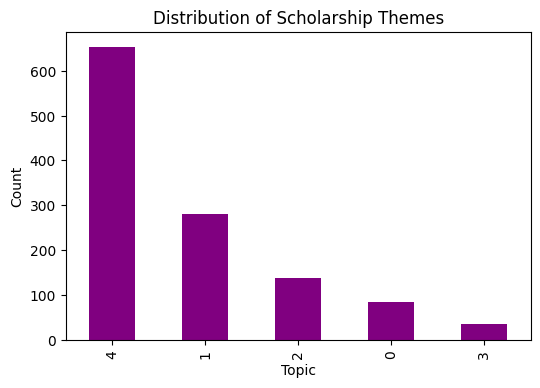

In [13]:
plt.figure(figsize=(6,4))
df["Topic"].value_counts().plot(kind="bar", color="purple")
plt.title("Distribution of Scholarship Themes")
plt.xlabel("Topic")
plt.ylabel("Count")
plt.show()